# 空转分群

- coder: yangdong, yinzhanhao
- date: 2605
- BayesSpace [github](https://github.com/edward130603/BayesSpace) [tutorial](https://www.ezstatconsulting.com/BayesSpace/articles/BayesSpace.html)
- image: SuperCells_scRNA_analysis_Packages_V3

In [2]:
suppressPackageStartupMessages({
    library(SingleCellExperiment)
    library(ggplot2)
    library(BayesSpace)
    library(Seurat)
    library(cowplot)
    library(RColorBrewer)
    library(stringr)
    library(Seurat)
    library(SeuratDisk)
})

In [3]:
rds_path <- "/data/work/m1.rds"
sample_key <- 'sample'
log_method <- 'sct'
clus <- 6

In [4]:
seurat_spatialObj <- readRDS(rds_path)

- what is qplot?
  - 空间聚类（spatialCluster）中负对数似然值（Negative Log Likelihood）随分群数（q）变化的曲线。在统计模型中，负对数似然值越低，通常意味着模型对数据的拟合程度越好。要选择合适的分群数，可以参考以下几个维度：寻找“拐点”（Elbow Method）；观察稳定性与平台期（Plateau）；结合生物学背景（Biological Context）

In [5]:
seurat_spatialObj

An object of class Seurat 
13536 features across 1891 samples within 1 assay 
Active assay: Spatial (13536 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: spatial

In [8]:
# # seurat_spatialObj@images
# # 使用stereopy的h5ad2rds转换后是没有@images的
# seurat_spatialObj@meta.data$row = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$x
# seurat_spatialObj@meta.data$col = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$y

if ("x" %in% colnames(seurat_spatialObj@meta.data) && "y" %in% colnames(seurat_spatialObj@meta.data)){
    seurat_spatialObj$row <- seurat_spatialObj$x
    seurat_spatialObj$col <- seurat_spatialObj$y
}

## Log normalization or other normalization

In [9]:
if(log_method=='log'){
    seurat_spatialObj <- NormalizeData(seurat_spatialObj)
    seurat_spatialObj <- FindVariableFeatures(seurat_spatialObj)
    seurat_spatialObj <- ScaleData(seurat_spatialObj)
    sce <- as.SingleCellExperiment(seurat_spatialObj)
    sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
} else if(log_method=='sct'){
    seurat_spatialObj=SCTransform(seurat_spatialObj, assay = "Spatial", verbose = FALSE)
    sce <- as.SingleCellExperiment(seurat_spatialObj, assay="SCT")
    sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
}

In [10]:
sce

class: SingleCellExperiment 
dim: 3525 1891 
metadata(1): BayesSpace.data
assays(2): counts logcounts
rownames(3525): CP000013 CP000017 ... MT052048 MT052057
rowData names(1): is.HVG
colnames(1891): 60902636269820 60902636269840 ... 65283502912080
  65283502912100
colData names(13): X_index nCount_Spatial ... col ident
reducedDimNames(2): SPATIAL PCA
mainExpName: SCT
altExpNames(0):

## cluster

- `spatialCluster()`
    - `q` Number of clusters
    - `d` Number of PCs
- **cluster methods** [from](https://www.ezstatconsulting.com/BayesSpace/articles/maynard_DLPFC.html)
  - manual (stereopy interactive mode)
  - Non-spatial clustering algorithms
  - Spatial clustering algorithms
- **Q&A**: how to select best method and parameters (cluster number, pc number)

Neighbors were identified for 0 out of 1891 spots.

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...



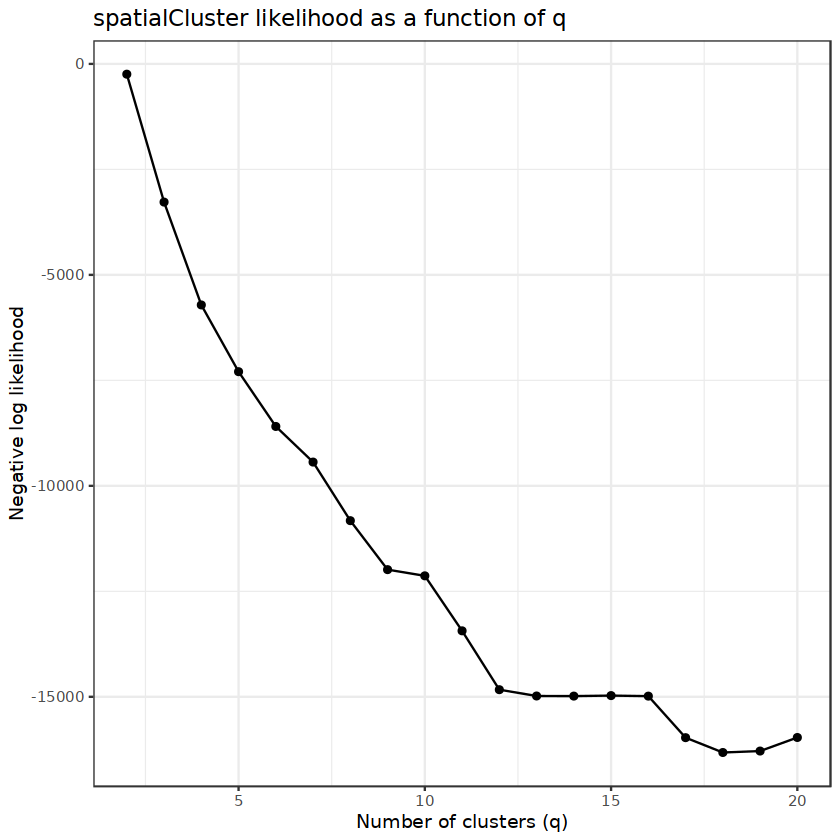

In [11]:
# determine the optimal number of clusters
sce <- qTune(sce, qs=seq(2, 20), platform="ST", d=13)
qPlot(sce)

In [12]:
# fast version
# note: spatialCluster要求数据必须在meta.data包含col和row
# row (x coordinates) and col (y coordinates)
sce <- spatialCluster(sce, q=clus, platform="ST", d=8,
                    init.method="mclust", model="t", gamma=2,
                    nrep=10000, burn.in=100,
                    save.chain=TRUE)
# clusterPlot(sce)

Neighbors were identified for 0 out of 1891 spots.

Fitting model...

Calculating labels using iterations 100 through 10000.



In [ ]:
sce <- spatialCluster(sce, q=clus, platform="ST", d=30,
                    init.method="mclust", model="t", gamma=2,
                    nrep=50000, burn.in=100,
                    save.chain=TRUE)

Neighbors were identified for 0 out of 1891 spots.

Fitting model...



## plot

In [15]:
pale<-c(brewer.pal(12,"Set3"),brewer.pal(9,"Set1"),brewer.pal(8,"Dark2"),brewer.pal(12,"Paired"))
temp <- as.data.frame(colData(sce))
head(temp)

,X_index,nCount_Spatial,nFeature_Spatial,orig.ident,percent.mito,sample,x,y,nCount_SCT,nFeature_SCT,row,col,ident,cluster.init,spatial.cluster
,<chr>,<int>,<int>,<fct>,<dbl>,<fct>,<int>,<int>,<dbl>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>
60902636269820,60902636269820,18,11,sample,0,m1,14180,12540,24,9,14180,12540,AnnData,1,1
60902636269840,60902636269840,27,20,sample,0,m1,14180,12560,26,14,14180,12560,AnnData,2,2
60902636269860,60902636269860,29,23,sample,0,m1,14180,12580,23,17,14180,12580,AnnData,2,2
60902636269880,60902636269880,12,11,sample,0,m1,14180,12600,24,9,14180,12600,AnnData,2,2
60902636269900,60902636269900,9,8,sample,0,m1,14180,12620,22,7,14180,12620,AnnData,2,2
60902636269920,60902636269920,47,24,sample,0,m1,14180,12640,41,18,14180,12640,AnnData,3,5


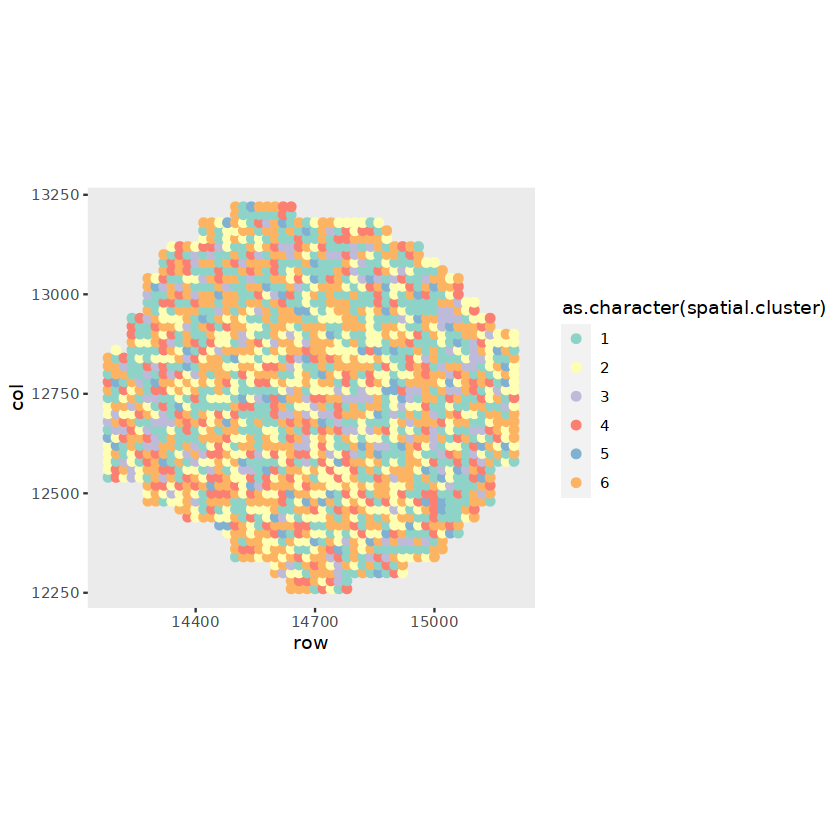

In [16]:
ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
       scale_colour_discrete(type=pale,na.value="grey")+
       theme(panel.grid=element_blank())+
       coord_fixed() 

## save

In [21]:
sce

class: SingleCellExperiment 
dim: 3525 1891 
metadata(2): BayesSpace.data chain.h5
assays(2): counts logcounts
rownames(3525): CP000013 CP000017 ... MT052048 MT052057
rowData names(1): is.HVG
colnames(1891): 60902636269820 60902636269840 ... 65283502912080
  65283502912100
colData names(15): X_index nCount_Spatial ... cluster.init
  spatial.cluster
reducedDimNames(2): SPATIAL PCA
mainExpName: SCT
altExpNames(0):

In [18]:
rds2h5ad <- function(sce){
    sce.seurat <- as.Seurat(sce, counts="counts", data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@meta.data[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq', assay = "Spatial", coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".", log_method, ".fast.h5Seurat"), assay="Spatial", overwrite=TRUE)
    Convert(paste0(sample, ".", log_method, ".fast.h5Seurat"), dest = "h5ad", overwrite=TRUE)
}

In [25]:
sce.seurat <- CreateSeuratObject(counts = counts(sce))
sce.seurat[["RNA"]]$data <- logcounts(sce)

for(col in colnames(colData(sce))) {
    sce.seurat[[col]] <- colData(sce)[[col]]
}

In [26]:
sce.seurat

An object of class Seurat 
3525 features across 1891 samples within 1 assay 
Active assay: RNA (3525 features, 0 variable features)
 2 layers present: counts, data

In [ ]:
# for(sample in unique(temp0@meta.data[[sample_key]])){
#     seurat_spatialObj <- temp0.list[[sample]]
#     set.seed(1234)
#     seurat_spatialObj@meta.data$row = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$x
#     seurat_spatialObj@meta.data$col = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$y

#     # different normalization methods
#     if(log_method=='log'){
#         seurat_spatialObj <- NormalizeData(seurat_spatialObj)
#         seurat_spatialObj <- FindVariableFeatures(seurat_spatialObj)
#         seurat_spatialObj <- ScaleData(seurat_spatialObj)
#         sce <- as.SingleCellExperiment(seurat_spatialObj)
#         sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
#     } else if(log_method=='sct'){
#         seurat_spatialObj=SCTransform(seurat_spatialObj, assay = "Spatial", verbose = FALSE)
#         sce <- as.SingleCellExperiment(seurat_spatialObj,assay="SCT")
#         sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
#     }

#     # determine the optimal number of clusters
#     sce <- qTune(sce, qs=seq(2, 20), platform="ST", d=13)
#     qPlot(sce)

#     # fast version
#     sce <- spatialCluster(sce, q=clus, platform="ST", d=8,
#                         init.method="mclust", model="t", gamma=2,
#                         nrep=3000, burn.in=100,
#                         save.chain=TRUE)
    
#     sce.seurat <- as.Seurat(sce, counts="counts", data="logcounts")
#     Idents(sce.seurat) <- "spatial.cluster"
#     locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
#     sce.seurat[['image']] <- new(Class = 'SlideSeq', assay = "Spatial", coordinates = locations)
#     SaveH5Seurat(sce.seurat, filename = paste0(sample,".", log_method, ".fast.h5Seurat"), assay="Spatial", overwrite=TRUE)
#     Convert(paste0(sample,".",log_method,".fast.h5Seurat"), dest = "h5ad", overwrite=TRUE)
    
#     # slow version
#     sce <- spatialCluster(sce, q=clus, platform="ST", d=30,
#                     init.method="mclust", model="t", gamma=2,
#                     nrep=50000, burn.in=100,
#                     save.chain=TRUE)
#     sce.seurat <- as.Seurat(sce,counts="counts",data="logcounts")
#     Idents(sce.seurat) <- "spatial.cluster"
#     locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
#     sce.seurat[['image']] <- new(Class = 'SlideSeq',assay = "Spatial",coordinates = locations)
#     SaveH5Seurat(sce.seurat, filename = paste0(sample,".",log_method,".fine.h5Seurat"),assay="Spatial",overwrite=TRUE)
#     Convert(paste0(sample,".",log_method,".fine.h5Seurat"), dest = "h5ad",overwrite=TRUE)
# }